# P9: Interpretability

**Turn a group-level CPP signature into a per-sample, single-residue explanation: SHAP and the CPP-SHAP heatmap.** A CPP *signature* (P1) tells you which position-resolved physicochemical features separate a **test group** (`label=1`) from a **reference group** (`label=0`) *on average*. This protocol goes one level deeper: given that signature and a fitted tree model, `ShapModel` computes SHapley Additive exPlanations (SHAP) values, the signed contribution of each feature to **one** protein's prediction score. The sample-level `CPPPlot.heatmap` (with `shap_plot=True`) then anchors those signed attributions onto the real residue positions of a single protein, so the explanation reads like *"this protein's TMD hydrophobicity at this position raised its substrate score"* rather than an abstract feature index.

The signature is the *group* story; SHAP is the *per-protein* story. **Feature importance** is unsigned and group-level (*how much does this feature matter overall?*); **feature impact** is signed and sample-level (*how much, and in which direction, did this feature push the score for this one protein?*): red pushes toward the test class, blue toward the reference class. Read one sample's impact as a local explanation, not as a new group claim.

We stay at the **domain level** (dataset prefix `DOM_`): the **unit of comparison** is the transmembrane-domain (TMD) part set of the gamma-secretase substrate task (`DOM_GSEC`), and we explain a single protein, APP, within it.

**When to use it.** Use this protocol when you already have a **CPP signature** (`df_feat`) plus a labelled **feature matrix**, and you want to explain a *single protein's* prediction rather than the group as a whole. The biological question shifts from *"what distinguishes substrates from non-substrates?"* (determinant discovery, P1) to:

> *"Why does the model classify **this** protein (e.g. APP) as a gamma-secretase substrate, and **where** in its sequence do the decisive physicochemical differences act?"*

This is the protein-prediction analogue of a feature-attribution map (LIME / SHAP) in deep learning, but every attribution is anchored to an interpretable physicochemical scale and to a concrete residue position, not a black-box embedding dimension.

**When *not* to use it.** SHAP *explains*; it does not establish *trust*. Don't use a single sample's feature impact to make a **group** claim ("this scale defines substrates"): that is the signature's job (P1). Don't read it as proof the model generalizes: attributions are sample- and model-specific, and a model fit on a tiny set can attribute confidently to noise, so stability and controls come next (P10). And skip it entirely if you only need a ranked group signature: `TreeModel.add_feat_importance` already gives the unsigned, group-level ranking without fitting SHAP.

**Input.** This protocol receives its signature from **P1: CPP signature** and a fitted tree model from **P7: Build an interpretable classifier**. Concretely it needs:

- **`df_seq`** with a binary `label` column (test group = 1, reference group = 0). Here: the bundled `DOM_GSEC` set (gamma-secretase substrates vs. non-substrates), a **domain-level** task over the TMD and its flanking juxtamembrane (JMD) parts.
- **`df_feat`**, the CPP **signature** from *P1* (`aa.load_features(name="DOM_GSEC")` provides a precomputed signature here so this protocol stays self-contained).
- **`X`**, the `(n_samples, n_features)` feature matrix built from `df_feat["feature"]` via `SequenceFeature.feature_matrix`.
- **`labels`**, the class vector aligned to the rows of `X`.

We pick one protein to explain: **APP** (UniProt `P05067`), the Alzheimer's-disease amyloid precursor protein and a canonical gamma-secretase substrate.

In [1]:
import aaanalysis as aa
import matplotlib.pyplot as plt

aa.options["verbose"] = False
aa.options["random_state"] = 42

# Small fixture: 50 per class (100 proteins total) keeps SHAP fitting fast
df_seq = aa.load_dataset(name="DOM_GSEC", n=50)
labels = df_seq["label"].to_list()

# CPP signature (from Protocol 1) and the feature matrix it indexes
df_feat = aa.load_features(name="DOM_GSEC")
sf = aa.SequenceFeature()
df_parts = sf.get_df_parts(df_seq=df_seq)
X = sf.feature_matrix(df_parts=df_parts, features=df_feat["feature"])

# Locate APP's row in X (non-substrates come first, so APP is NOT index 0; it sits at 50)
pos_app = list(df_seq["entry"]).index("P05067")

**Run.** Four steps, all on the real API (see the ShapModel tutorial for the function details):

1. **Fit `ShapModel`**: trains the tree models and runs the SHAP explainer over several Monte-Carlo rounds, storing the per-sample attributions in `shap_values`.
2. **Add the feature value difference** for APP (`add_sample_mean_dif`): how APP's feature values differ from the reference-group average.
3. **Add the feature impact** for APP (`add_feat_impact`): the signed, normalized SHAP attribution per feature.
4. **Visualize** with the sample-level `CPPPlot` methods (`shap_plot=True`).

In [2]:
# Fit ShapModel (pro feature; shap ships with the `pro` extra)
try:
    sm = aa.ShapModel(verbose=False, random_state=42)
    sm = sm.fit(X, labels=labels, n_rounds=3)  # 3 rounds is enough for a demo fixture
except ImportError as e:
    raise ImportError("ShapModel requires shap: pip install aaanalysis[pro]") from e

# Feature value difference: APP vs. the reference (non-substrate) group average
df_feat = sm.add_sample_mean_dif(X, labels=labels, df_feat=df_feat,
                                 samples=pos_app, names="APP")

In [3]:
# Signed SHAP feature impact for APP (normalized to % of total absolute impact)
df_feat = sm.add_feat_impact(df_feat=df_feat, samples=pos_app, names="APP")

aa.display_df(df=df_feat[["feature", "category", "mean_dif_APP", "feat_impact_APP"]], n_rows=8)

,feature,category,mean_dif_APP,feat_impact_APP
1,"TMD_C_JMD_C-Seg...3,4)-KLEP840101",Energy,0.224000,0.660000
2,"TMD_C_JMD_C-Seg...3,4)-FINA910104",Conformation,0.194644,1.280000
3,"TMD_C_JMD_C-Seg...6,9)-LEVM760105",Shape,0.300050,1.570000
4,"TMD_C_JMD_C-Seg...3,4)-HUTJ700102",Energy,0.177140,3.050000
5,"TMD_C_JMD_C-Seg...6,9)-RADA880106",ASA/Volume,0.201494,1.300000
6,"TMD_C_JMD_C-Seg...2,3)-KLEP840101",Energy,0.167146,1.250000
7,"TMD_C_JMD_C-Seg...4,5)-FAUJ880109",Energy,0.146250,0.210000
8,"TMD_C_JMD_C-Seg...3,4)-JANJ780101",ASA/Volume,0.373808,0.540000


In [4]:
# APP's sequence parts, used to anchor the plots to real residues
seq_kws = sf.get_seq_kws(df_seq=df_seq, df_parts=df_parts, sample="P05067")

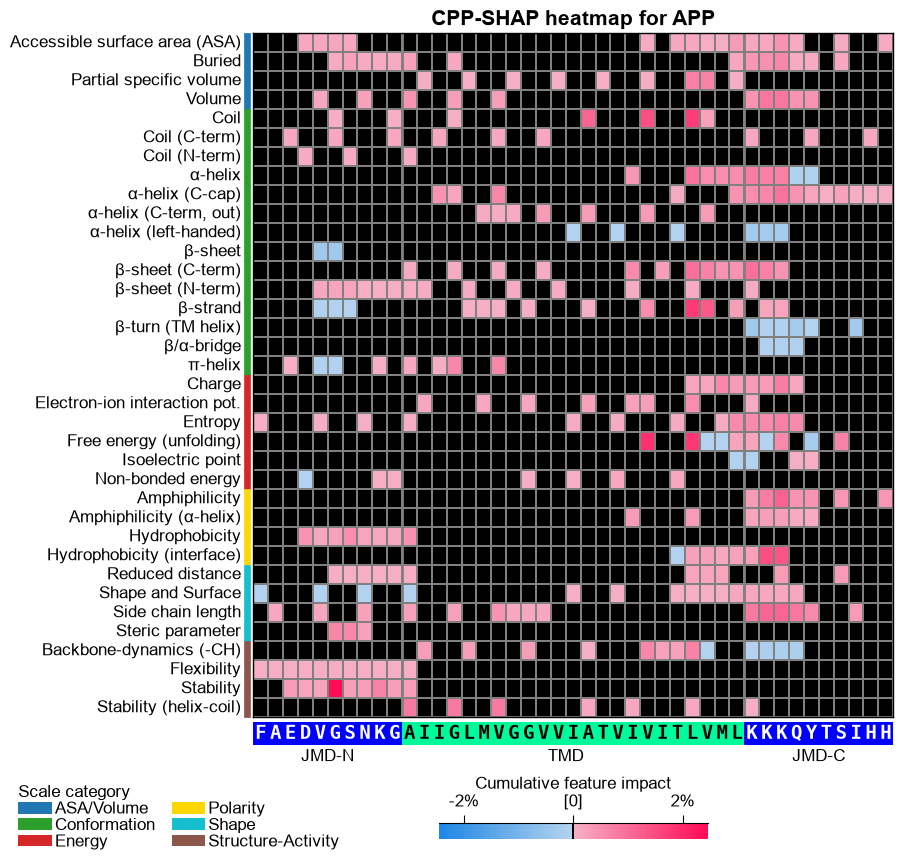

In [5]:
# CPP-SHAP heatmap (sample level): the headline figure.
# Each cell is the SIGNED SHAP impact of one feature on APP's substrate score,
# anchored to its real residue position and scale subcategory
# (red = pushes APP toward "substrate", blue = pushes toward "non-substrate").
fs = aa.plot_gcfs()
aa.plot_settings(font_scale=0.65, weight_bold=False)
cpp_plot = aa.CPPPlot()
fig, ax = cpp_plot.heatmap(df_feat=df_feat, shap_plot=True,
                           col_val="feat_impact_APP", name_test="APP", **seq_kws)
plt.title("CPP-SHAP heatmap for APP", fontsize=fs + 5, weight="bold")
plt.show()

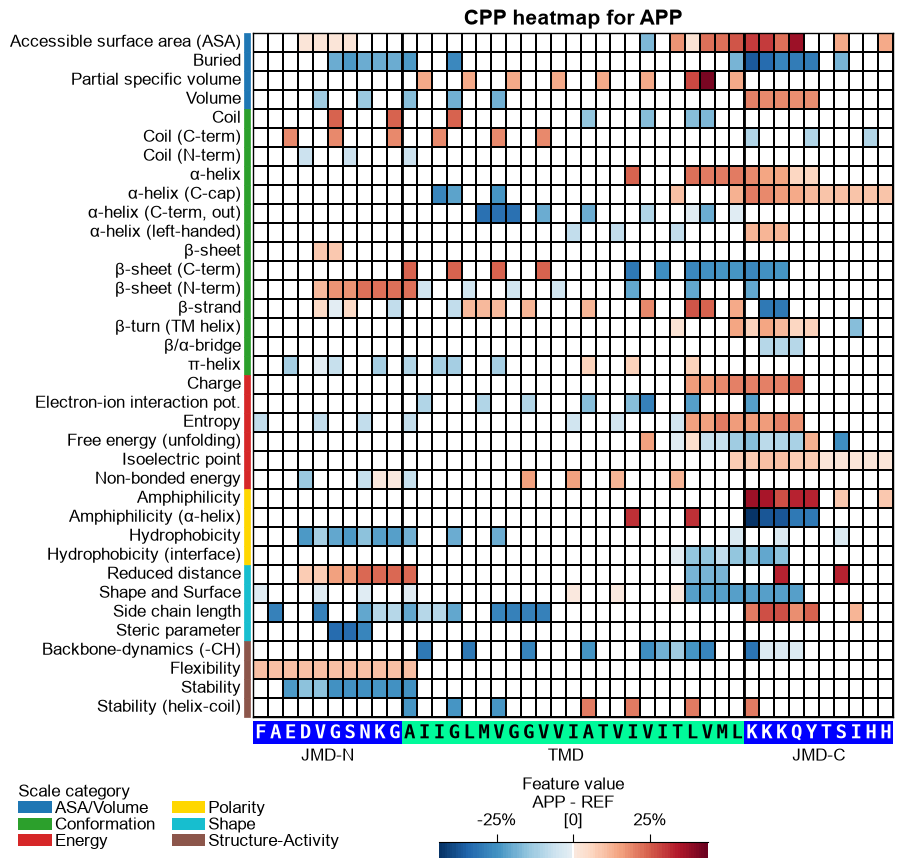

In [6]:
# CPP heatmap (sample level, mean-difference mode):
# each cell is APP's feature VALUE difference vs. the reference-group average,
# per scale subcategory and residue position (the complement to the impact heatmap above).
aa.plot_settings(font_scale=0.65, weight_bold=False)
fig, ax = cpp_plot.heatmap(df_feat=df_feat, shap_plot=True,
                           col_val="mean_dif_APP", name_test="APP", **seq_kws)
plt.title("CPP heatmap for APP", fontsize=fs + 5, weight="bold")
plt.show()

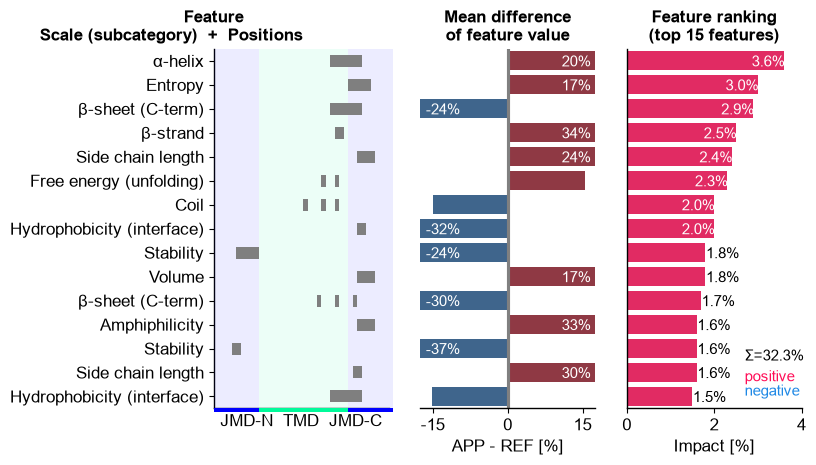

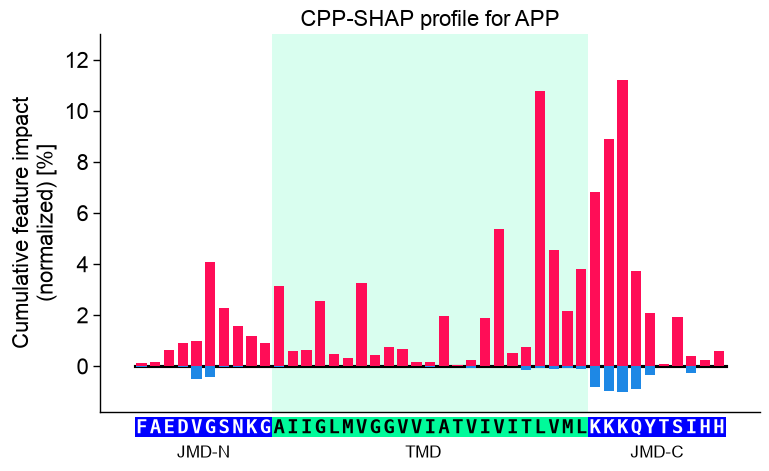

In [7]:
# CPP-SHAP ranking: top features for APP ordered by impact magnitude
aa.plot_settings(short_ticks=True, weight_bold=False)
fig, ax = cpp_plot.ranking(df_feat=df_feat, shap_plot=True,
                           col_dif="mean_dif_APP", col_imp="feat_impact_APP",
                           name_test="APP")
plt.tight_layout()
plt.show()

# CPP-SHAP profile: cumulative signed impact per residue position along APP
aa.plot_settings(font_scale=0.9)
fig, ax = cpp_plot.profile(df_feat=df_feat, shap_plot=True,
                           col_imp="feat_impact_APP", **seq_kws)
plt.title("CPP-SHAP profile for APP")
plt.tight_layout()
plt.show()

**Output.** `df_feat` gains two sample-level columns:

- `mean_dif_APP`: APP's feature value difference vs. the reference-group average (sign = direction).
- `feat_impact_APP`: the signed SHAP attribution per feature, normalized so the absolute values sum to 100%.

Sample-level CPP-SHAP figures:

1. **CPP-SHAP heatmap (impact mode)**: the headline figure; each cell is the signed SHAP impact of one feature on APP's score (diverging colormap, red positive / blue negative), per scale subcategory and residue position.
2. **CPP heatmap (mean-difference mode)**: each cell is APP's feature *value* difference vs. the reference-group average, the complement that shows *where* APP physically differs.
3. **Ranking**: APP's top features ordered by impact magnitude.
4. **Profile**: cumulative signed impact along the residue positions of APP's JMD-N / TMD / JMD-C.

Every figure is anchored to APP's actual sequence (`jmd_n`, `tmd`, `jmd_c`), so an attribution can be read off a specific residue.

**How to interpret.** A few things are happening in these figures. The heatmap row tells you *which physicochemical subcategory* and *where* along APP's parts; the color tells you *direction*; the cumulative bars sum the signed impact per residue position. Read them like this:

| Element | Reading |
| --- | --- |
| **red bar / cell** | feature's SHAP impact is **positive**, pushing APP toward the **test group** (substrate) |
| **blue bar / cell** | feature's SHAP impact is **negative**, pushing APP toward the **reference group** (non-substrate) |
| **tall / saturated segment** | feature contributes strongly in that direction |
| **bar width at position _x_** | cumulative impact from all features acting at residue position _x_ |
| **heatmap cell, mean-diff mode** | APP's *feature value* difference (test minus reference) at one position/scale |
| **heatmap cell, impact mode** | the *signed contribution* of that one feature to APP's score |

**Worked reading (a recipe, not a claim about APP).** This is the *template* you apply to whatever your own figure shows. For example, *if* you see a tall red bar over a TMD position whose row is a hydrophobicity subcategory, read it as: APP's hydrophobicity is higher than the reference-group average there, and that excess hydrophobicity raised the classifier's substrate score for APP. Swap in the actual subcategory, position, and color you observe: the figure, not this sentence, is the source of truth.

**Key takeaways**

- **Coherent same-color blocks** (e.g. red hydrophobicity across the TMD core) are a consistent, reliable local signal; **isolated single cells** are weak or conflicting evidence, so don't over-read them.
- **Sign agreement** between `mean_dif_APP` and `feat_impact_APP` means APP follows the group trend the model learned (a confidence boost); a **sign mismatch** flags a possible outlier or a non-linear effect, so interpret with care.
- This is *one* protein's local explanation. A high-impact feature for APP is **not** automatically a group determinant, so cross-check against the signature (P1) before generalizing.

**Common mistakes.**

- **Calling `add_feat_impact` before `fit`**: `shap_values` is unset until `ShapModel.fit` runs, so impact cannot be computed.
- **Assuming the sample is at index 0**: with `load_dataset(name="DOM_GSEC", n=50)` the reference class (label 0) comes first, so APP sits at position 50, not 0. Always resolve the position from the entry (here `list(df_seq["entry"]).index("P05067")`).
- **Mismatching `shap_plot` and the column**: when `shap_plot=True`, `col_val` must be a per-sample column. Use `feat_impact_'name'` (signed) for the CPP-SHAP impact heatmap and `mean_dif_'name'` for the feature-value heatmap, **not** the group-level `feat_importance` (unsigned). The two are semantically opposite.
- **Treating `CPPPlot.heatmap` as static**: it is an *instance* method (`aa.CPPPlot().heatmap(...)`).
- **Over-generalizing one sample**: SHAP values are sample- and model-specific. A high-impact feature for APP does not mean it generalizes to all substrates; cross-check against the group signature (P1).
- **Forgetting the `pro` extra**: `ShapModel` needs shap (`pip install aaanalysis[pro]`).

**Next step.** **P10: Validation** (can I trust this?). Before reading a single sample's explanation as biology, test the signature's stability:

- **Repeated cross-validation**: refit CPP + `ShapModel` over random splits; do the SHAP rankings converge?
- **Feature-drop tests**: remove top-impact features one at a time; does performance degrade as expected?
- **Shuffled-label controls**: refit on permuted labels; genuine impacts should collapse to noise.
- **Bootstrap confidence intervals**: resample proteins within each class; do the attributions stay consistent?

See *P10: Validation*.